In [ ]:
!pip install -q kagglehub ultralytics openpyxl seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.3 MB/s eta 0:00:00


In [ ]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Dataset downloaded to:", path)

# Train directory
train_dir = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)",
    "train"
)

print("Train directory:", train_dir)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Dataset downloaded to: /kaggle/input/new-plant-diseases-dataset
Train directory: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train


In [ ]:
import os
import pandas as pd

class_counts = {}

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)
    if os.path.isdir(class_path):
        class_counts[cls] = len(os.listdir(class_path))

df = pd.DataFrame(class_counts.items(), columns=["Class", "Image_Count"])
df = df.sort_values("Image_Count", ascending=False)

total_images = df["Image_Count"].sum()

print("Total Classes:", len(df))
print("Total Images:", total_images)

df.head(10)

Total Classes: 38
Total Images: 70295


,Class,Image_Count
4,Soybean___healthy,2022
13,Apple___Apple_scab,2016
3,Orange___Haunglongbing_(Citrus_greening),2010
27,Apple___healthy,2008
22,"Pepper,_bell___healthy",1988
16,Apple___Black_rot,1987
14,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961
29,Potato___Early_blight,1939
24,Potato___Late_blight,1939
1,Tomato___healthy,1926


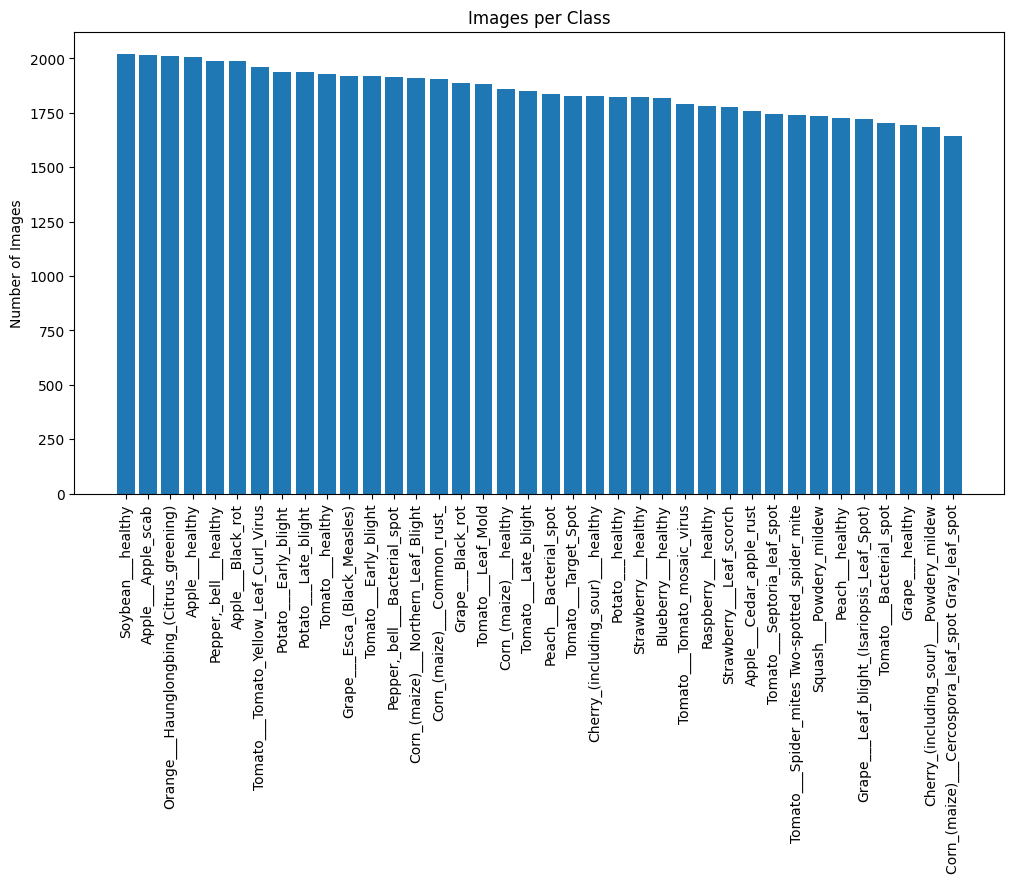

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(df["Class"], df["Image_Count"])
plt.xticks(rotation=90)
plt.title("Images per Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tqdm import tqdm
from PIL import Image

IMG_SIZE = (224,224)

base_model = MobileNetV3Small(weights="imagenet", include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base_model.output)

feature_model = Model(inputs=base_model.input, outputs=x)

records = []

for cls in tqdm(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, cls)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path)[:300]:   # limit for speed
        img_path = os.path.join(class_path, img_name)

        try:
            img = image.load_img(img_path, target_size=IMG_SIZE)
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)

            features = feature_model.predict(img_array, verbose=0)[0]

            # color stats
            im = Image.open(img_path).convert("RGB")
            arr = np.array(im)/255.0

            mean_r, mean_g, mean_b = arr.mean(axis=(0,1))

            row = {
                "filename": img_name,
                "class": cls,
                "mean_r": mean_r,
                "mean_g": mean_g,
                "mean_b": mean_b
            }

            for i,f in enumerate(features[:50]):   # first 50 deep features
                row[f"feat_{i}"] = f

            records.append(row)

        except:
            continue

features_df = pd.DataFrame(records)

excel_file = "dataset_features.xlsx"
features_df.to_excel(excel_file, index=False)

print("Feature Excel saved:", excel_file)
features_df.head()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


100%|██████████| 38/38 [16:49<00:00, 26.56s/it]


Feature Excel saved: dataset_features.xlsx


,filename,class,mean_r,mean_g,mean_b,feat_0,feat_1,feat_2,feat_3,feat_4,...,feat_40,feat_41,feat_42,feat_43,feat_44,feat_45,feat_46,feat_47,feat_48,feat_49
0,781e93a9-2059-42de-8075-658033a6abf7___RS_Late...,Tomato___Late_blight,0.463037,0.486084,0.455847,1.083976,1.597742,1.057563,-0.061437,-0.103562,...,-0.052119,0.933038,0.289516,0.216832,-0.062587,-0.139452,0.959648,0.075997,0.173839,0.176455
1,1e0c01b6-5d75-47ea-b455-c9508882424a___RS_Late...,Tomato___Late_blight,0.622673,0.624647,0.559417,1.308598,1.242410,1.491580,1.046716,-0.046435,...,-0.040926,1.880640,0.254991,1.152896,-0.030128,0.025959,0.854224,0.051793,0.273620,0.267174
2,283ff0be-6e5e-4b4e-bf21-639780b77ffc___GHLB2 L...,Tomato___Late_blight,0.434258,0.444453,0.461648,0.657466,1.066228,0.245772,-0.163046,0.104482,...,-0.165001,0.564539,0.231508,1.804946,-0.104708,0.175189,0.041602,0.052581,0.100503,0.519981
3,0db85707-41f9-42df-ba3b-842d14f00a68___GHLB2 L...,Tomato___Late_blight,0.484738,0.482926,0.473457,1.132363,1.280880,0.246575,-0.086545,-0.141794,...,-0.119636,0.374137,1.386002,1.307556,-0.083730,0.206598,0.242167,-0.036237,-0.026396,-0.046781
4,3ae2b5f3-a42f-49b1-8d27-dcfaaeda602f___GHLB2 L...,Tomato___Late_blight,0.463296,0.434657,0.402809,1.794227,-0.017182,0.066268,-0.157830,0.130586,...,-0.074453,0.565772,0.729073,1.518276,-0.091762,0.287327,0.248843,0.092474,0.048950,0.083255


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

class_names = train_ds.class_names
print("Classes:", len(class_names))

Found 70295 files belonging to 38 classes.
Using 56236 files for training.
Found 70295 files belonging to 38 classes.
Using 14059 files for validation.
Classes: 38


In [ ]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV3Small(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(base_model.input, outputs)

for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling_1[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation_18[0]… │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu_14[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 1, 1, 16)  │          0 │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 1, 1, 16)  │          0 │ re_lu_15[0][0]    │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu_14[0][0],   │
│ (Multiply)          │ 16)               │            │ multiply_9[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,096,598 (4.18 MB)

 Trainable params: 157,478 (615.15 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
import shutil
import os
from ultralytics import YOLO

# writable directory
yolo_data_dir = "/content/plant_dataset"

# copy dataset from kagglehub location
if not os.path.exists(yolo_data_dir):
    shutil.copytree(train_dir, yolo_data_dir)

print("Dataset copied to:", yolo_data_dir)

# load YOLO classification model
yolo_model = YOLO("yolov8n-cls.pt")

# train
yolo_model.train(
    data=yolo_data_dir,
    epochs=15,
    imgsz=224,
    batch=32
)

Dataset copied to: /content/plant_dataset
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/plant_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d30af7ba090>
curves: []
curves_results: []
fitness: 0.9985436201095581
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9970872402191162, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9985436201095581}
save_dir: PosixPath('/content/runs/classify/train2')
speed: {'preprocess': 0.079805799800579, 'inference': 0.2558315285607334, 'loss': 0.00030787340157120154, 'postprocess': 0.00045185038359838657}
task: 'classify'
top1: 0.9970872402191162
top5: 1.0

In [ ]:
loss, acc = model.evaluate(val_ds)

print("MobileNet Accuracy:", acc)

440/440 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.9812 - loss: 0.0629
MobileNet Accuracy: 0.9816487431526184


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

mobile_preds = []
true_labels = []

for images, labels in val_ds:
    preds = model.predict(images)
    mobile_preds.extend(np.argmax(preds, axis=1))
    true_labels.extend(labels.numpy())

mobile_preds = np.array(mobile_preds)
true_labels = np.array(true_labels)

acc_mobile = accuracy_score(true_labels, mobile_preds)

print("MobileNet Accuracy:", acc_mobile)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━

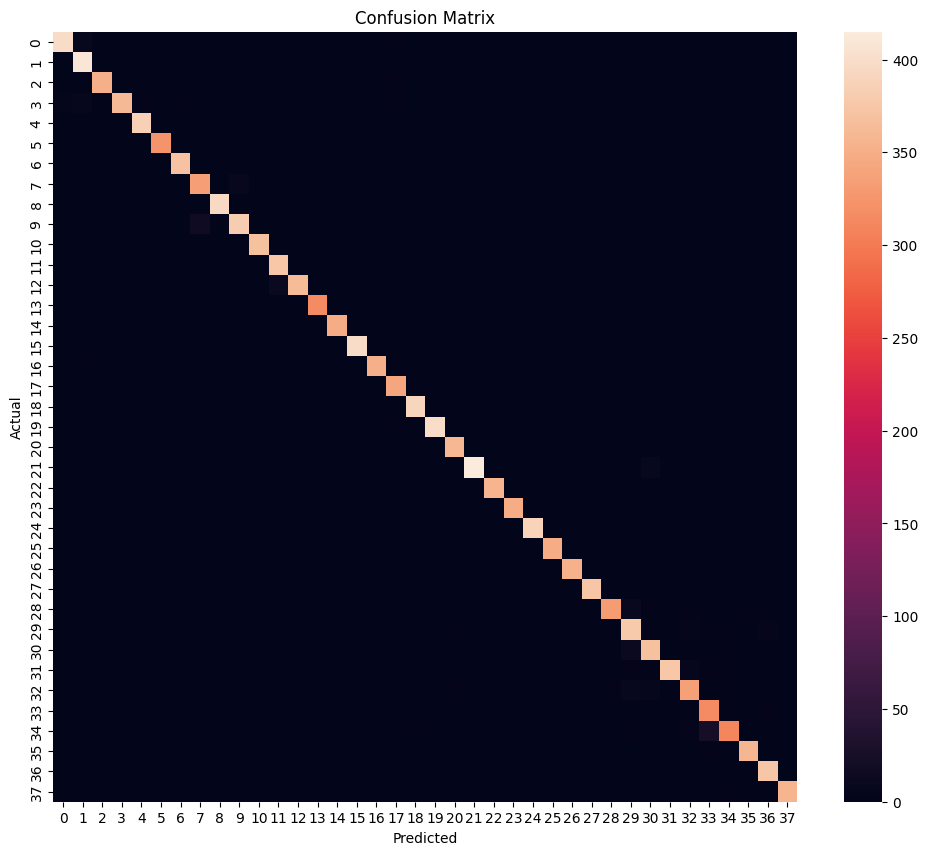

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, mobile_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from google.colab import files

files.download("mobilenet_plant_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("dataset_features.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model loaded successfully

📂 Upload a plant leaf image


Saving leaf.jpg to leaf (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

🌿 Predicted Disease: Tomato___Late_blight
Confidence: 100.0 %


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1303']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


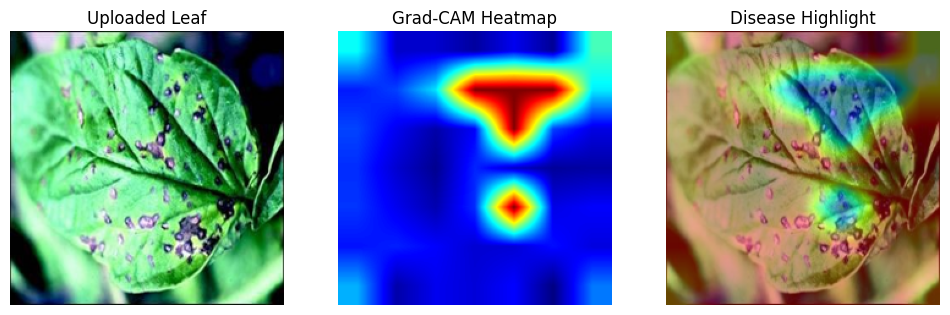

In [ ]:
# ================= FINAL PLANT DISEASE PREDICTION + XAI =================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from google.colab import files

from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

IMG_SIZE = (224,224)

# -------- REBUILD MODEL ARCHITECTURE --------
base_model = MobileNetV3Small(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
outputs = Dense(38, activation="softmax")(x)

model = Model(base_model.input, outputs)

# -------- LOAD TRAINED WEIGHTS --------
model.load_weights("mobilenet_plant_model.h5")

print("✅ Model loaded successfully")

# -------- CLASS LABELS --------
class_names = [
"Apple___Apple_scab","Apple___Black_rot","Apple___Cedar_apple_rust","Apple___healthy",
"Blueberry___healthy","Cherry___Powdery_mildew","Cherry___healthy",
"Corn___Cercospora_leaf_spot Gray_leaf_spot","Corn___Common_rust","Corn___Northern_Leaf_Blight","Corn___healthy",
"Grape___Black_rot","Grape___Esca_(Black_Measles)","Grape___Leaf_blight","Grape___healthy",
"Orange___Haunglongbing","Peach___Bacterial_spot","Peach___healthy",
"Pepper_bell___Bacterial_spot","Pepper_bell___healthy",
"Potato___Early_blight","Potato___Late_blight","Potato___healthy",
"Raspberry___healthy","Soybean___healthy",
"Squash___Powdery_mildew",
"Strawberry___Leaf_scorch","Strawberry___healthy",
"Tomato___Bacterial_spot","Tomato___Early_blight","Tomato___Late_blight","Tomato___Leaf_Mold",
"Tomato___Septoria_leaf_spot","Tomato___Spider_mites","Tomato___Target_Spot",
"Tomato___Yellow_Leaf_Curl_Virus","Tomato___Mosaic_virus","Tomato___healthy"
]

# -------- IMAGE UPLOAD --------
print("\n📂 Upload a plant leaf image")
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# -------- PREPROCESS IMAGE --------
img = Image.open(img_path).convert("RGB")
img = img.resize(IMG_SIZE)

img_array = np.array(img) / 255.0
input_img = np.expand_dims(img_array, axis=0)

# -------- PREDICTION --------
prediction = model.predict(input_img)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

print("\n🌿 Predicted Disease:", class_names[predicted_class])
print("Confidence:", round(float(confidence)*100,2), "%")

# ================= GRAD-CAM EXPLAINABLE AI =================

# Find last convolution layer
last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer).output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(input_img)
    loss = predictions[:, predicted_class]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = heatmap.numpy()

heatmap = np.maximum(heatmap,0) / np.max(heatmap)

heatmap = cv2.resize(heatmap, (224,224))

# -------- HEATMAP OVERLAY --------
img_cv = cv2.imread(img_path)
img_cv = cv2.resize(img_cv,(224,224))

heatmap_uint = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(heatmap_uint, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(img_cv, 0.6, heatmap_color, 0.4, 0)

# -------- DISPLAY RESULTS --------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Uploaded Leaf")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap_color)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Disease Highlight")
plt.axis("off")

plt.show()

In [ ]:
# Save the already trained model
model.save("plant_disease_model.keras")

# Download to your computer
from google.colab import files
files.download("plant_disease_model.keras")

NameError: name 'model' is not defined